# 1. SMILES to SMIRKS
We will use the Indigo package to turn SMILES into SMIRKS

In [1]:
!pip install -q epam.indigo rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 21.6 MB/s eta 0:00:00


In [2]:
from indigo import Indigo
from rdkit.Chem import rdChemReactions

In [3]:
# rxn smiles
reactions = [
    "CCBr.O>>CCO",
    "CCO.CCBr>>CCOC",
    "c1ccccc1Br.O>>c1ccccc1O"
]

In [4]:
my_indigo = Indigo()

In [5]:
def smiles_to_smirks(rxn_smiles):
    '''
    Turn reaction SMILES into SMIKRS.
    '''
    rxn = my_indigo.loadReaction(rxn_smiles)

    # remove existing mapping and recompute
    rxn.automap("discard")

    return rxn.smiles()

In [6]:
mapped_reactions = []

for rxn in reactions:
    smirks = smiles_to_smirks(rxn)
    mapped_reactions.append(smirks)
    print("Original:", rxn)
    print("SMIRKS :", smirks)
    print()

Original: CCBr.O>>CCO
SMIRKS : [CH3:1][CH2:2]Br.[OH2:4]>>[CH3:1][CH2:2][OH:4]

Original: CCO.CCBr>>CCOC
SMIRKS : [CH3:1][CH2:2][OH:3].[CH3:4]CBr>>[CH3:1][CH2:2][O:3][CH3:4]

Original: c1ccccc1Br.O>>c1ccccc1O
SMIRKS : [cH:1]1[c:6](Br)[cH:5][cH:4][cH:3][cH:2]1.[OH2:8]>>[cH:1]1[c:6]([OH:8])[cH:5][cH:4][cH:3][cH:2]1



## Using RDKit to visualize and transform rxn strings

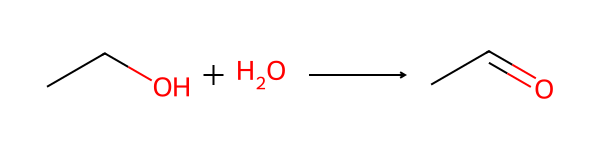

In [7]:
rxn = rdChemReactions.ReactionFromSmiles("CCO.O>>CC=O")
rxn

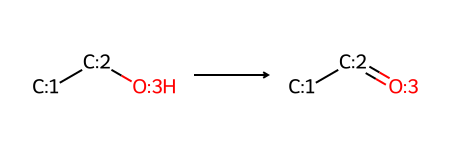

In [8]:
rxn_smiles = "[CH3:1][CH2:2][OH:3]>>[CH3:1][CH:2]=[O:3]"
rxn = rdChemReactions.ReactionFromSmiles(rxn_smiles)
rxn

## Mapping to SMIRKS
Note that RDKit does not explicitly generate the SMIRKS string, but use the atomic number of the smarts

In [9]:
smirks = rdChemReactions.ReactionToSmarts(rxn)
print(smirks)

[#6:1]-[#6:2]-[#8:3]>>[#6:1]-[#6:2]=[#8:3]


# 2. Retrosynthesis with Seq2Seq
We will build a Seq2Seq model to perform retrosynthesis.

In [10]:
import pandas as pd
import re # regular expression library, used for generating vocabulary

# torch imports
import torch
from torch.utils.data import Dataset
import torch.nn as nn
from torch.utils.data import DataLoader


## 1. Retrieve dataset
This time we are serious, and will not use toy datasets.


In [11]:
!wget -O uspto_rxn.csv -q "https://github.com/SunLab-Rutgers/chem542_CDS/raw/main/labs/lab14/data/uspto_2016.csv"

In [12]:
df = pd.read_csv("uspto_rxn.csv", index_col=False)[:1000] # only look at 1000 lines
df.head()

,reactant_smi,product_smi
0,C1(=CC=CC=C1)O.CN(C=O)C.[H-].[Na+].BrC1=CC=CC(...,CN1N=NN(C1=O)C1=C(C(=CC=C1)C)COC1=NC(=CC=C1)OC...
1,C(C)(=O)C=1C=C(OCC2=C(C=CC=C2C)N2N=NN(C2=O)C)C...,O(C1=CC=CC=C1)N=C(C)C=1C=C(OCC2=C(C=CC=C2C)N2N...
2,BrC=1C=C(OCC2=C(C=CC=C2C)N2N=NN(C2=O)C)C=CC1.C...,CN(C1=CC=CC=C1)C=1C=C(OCC2=C(C=CC=C2C)N2N=NN(C...
3,OC=1C=C(OCC2=C(C=CC=C2C)N2N=NN(C2=O)C)C=CC1.C(...,C(C1=CC=CC=C1)OC=1C=C(OCC2=C(C=CC=C2C)N2N=NN(C...
4,OCC=1C=C(OCC2=C(C=CC=C2C)N2N=NN(C2=O)C)C=CC1.B...,N1=C(C=CC=C1)OCC=1C=C(OCC2=C(C=CC=C2C)N2N=NN(C...


First, we turn a rxn SMILES string into tokens. E.g.,
`[CH3:1][CH2:2]Br.[OH2:4]` -> `([CH3:1], [CH2:2], Br, ., [OH2:4])`

In [13]:
# define split rules with re.compile()
SMILES_REGEX = r"(\[[^\[\]]+\]|Br?|Cl?|Si?|Se?|Na?|Li?|Mg?|Ca?|Al?|Zn?|Fe?|Cu?|Mn?|Hg?|Ag?|Sn?|Pb?|B|C|N|O|P|S|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\\\|\/|:|~|@|\?|>|%[0-9]{2}|[0-9])"
regex = re.compile(SMILES_REGEX)
def tokenize_smiles(smiles):
    return regex.findall(smiles)

In [15]:
# test our function
tokenize_smiles("[CH3:1][CH2:2]Br.[OH2:4]")

['[CH3:1]', '[CH2:2]', 'Br', '.', '[OH2:4]']

### Build Vocabulary


In [16]:
def build_vocab(smiles_list):
    '''
    Build vocabulary from a list of SMILES strings.
    Returns:
        smi2idx: dictionary of SMILES to index
        idx2smi: dictionary of index to SMILES
    '''
    tokens = set()
    for s in smiles_list:
        toks = tokenize_smiles(s)
        for t in toks:
            tokens.add(t)
    tokens = sorted(tokens)

    smi2idx = {t: i+4 for i, t in enumerate(tokens)}
    # add special tokens
    smi2idx["<pad>"] = 0 # padding: padding is usually zero so you can ignore it later
    smi2idx["<sos>"] = 1 # start of sequence
    smi2idx["<eos>"] = 2 # end of sequence
    smi2idx["<unk>"] = 3 # unknown token

    idx2smi = {i: s for s, i in smi2idx.items()}

    return smi2idx, idx2smi

In [17]:
# test our function
smi_list = ["[CH3:1][CH2:2]Br.[OH2:4]", "[CH3:1][CH:2]=[O:3]"]
smi2idx, idx2smi = build_vocab(smi_list)
print(smi2idx)

{'.': 4, '=': 5, 'Br': 6, '[CH2:2]': 7, '[CH3:1]': 8, '[CH:2]': 9, '[O:3]': 10, '[OH2:4]': 11, '<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3}


## Preprocess the dataset

In [18]:
# turn SMILES into sequence of tokens

class ReactionDataset(Dataset):
    def __init__(self, src_data, tgt_data, src_vocab, tgt_vocab, max_len=200):
        '''
        src_data: list of SMILES strings for the source
        tgt_data: list of SMILES strings for the target
        src_vocab: dictionary of SMILES to index for source (products)
        tgt_vocab: dictionary of SMILES to index for targets (reactants)
        max_len: maximum length of SMILES string
        '''
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len
        self.data = []
        assert len(src_data) == len(tgt_data)
        for i in range(len(src_data)):
            src_str = src_data[i]
            tgt_str = tgt_data[i]

            # turn rxn strings into sequence of indices of the tokens
            src_tokens = [src_vocab["<sos>"]] + \
                         [src_vocab.get(t, src_vocab["<unk>"]) for t in tokenize_smiles(src_str)] + \
                         [src_vocab["<eos>"]]

            tgt_tokens = [tgt_vocab["<sos>"]] + \
                         [tgt_vocab.get(t, tgt_vocab["<unk>"]) for t in tokenize_smiles(tgt_str)] + \
                         [tgt_vocab["<eos>"]]

            # src and tgt pairs
            self.data.append((src_tokens, tgt_tokens))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [23]:
# test our class
tgt_list = ["[CH3:1][CH2:2]Br.[OH2:4]"]
src_list = ["[CH3:1][CH:2]=[O:3]"]
src_vocab, _ = build_vocab("[CH3:1][CH:2]=[O:3]")
tgt_vocab, _ = build_vocab("[CH3:1][CH2:2]Br.[OH2:4]")

print(src_vocab)
my_dataset = ReactionDataset(src_list, tgt_list, src_vocab, tgt_vocab)
print(my_dataset.data[0])

{'1': 4, '2': 5, '3': 6, ':': 7, '=': 8, 'C': 9, 'H': 10, 'O': 11, '<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3}
([1, 3, 3, 8, 3, 2], [1, 3, 3, 3, 4, 3, 2])


In [24]:
# Add padding
def padding_dataset(batch):
    '''
    Add padding to the batch.
    '''
    src_batch, tgt_batch = zip(*batch)

    # get the maximum length
    src_max = max(len(x) for x in src_batch)
    tgt_max = max(len(x) for x in tgt_batch)

    # initialize a zero array
    src_padded = torch.zeros(len(batch), src_max, dtype=torch.long)
    tgt_padded = torch.zeros(len(batch), tgt_max, dtype=torch.long)

    # fill the zero array with original batch data
    for i, (s,t) in enumerate(batch):
        src_padded[i,:len(s)] = torch.tensor(s)
        tgt_padded[i,:len(t)] = torch.tensor(t)
    return src_padded, tgt_padded


## Construct the Seq2Seq model
We will use LSTM as the encoder and decoder

In [25]:

class RetroSeq2SeqLSTM(nn.Module):
    '''
    Seq2Seq model with LSTM encoder and decoder.
    '''
    def __init__(self, src_vocab_size, tgt_vocab_size,
                 emb_size=256, hidden_size=256, num_layers=3):
        '''
        src_vocab_size: size of source vocabulary
        tgt_vocab_size: size of target vocabulary
        emb_size: embedding size
        hidden_size: hidden size of LSTM
        num_layers: number of LSTM layers
        '''
        super().__init__()

        # embeddings
        self.src_embed = nn.Embedding(src_vocab_size, emb_size)
        self.tgt_embed = nn.Embedding(tgt_vocab_size, emb_size)

        # encoder
        self.encoder = nn.LSTM(
            emb_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        # decoder
        self.decoder = nn.LSTM(
            emb_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        # output projection
        self.fc = nn.Linear(hidden_size, tgt_vocab_size)

    def forward(self, src, tgt):
        '''
        src : product tokens of size [batch, src_len]
        tgt : reactant tokens of sieze [batch, tgt_len]

        '''
        # embed source
        src_emb = self.src_embed(src)
        # encoder forward
        _, (hidden, cell) = self.encoder(src_emb)

        # embed target
        tgt_emb = self.tgt_embed(tgt)
        # decoder forward
        out, _ = self.decoder(tgt_emb, (hidden, cell))

        # vocabulary prediction
        logits = self.fc(out)

        return logits

## Train the model

In [26]:
# load rxn strings
products = df["product_smi"]
reactants = df["reactant_smi"]

# build vocabularies
src_vocab, _ = build_vocab(products)
tgt_vocab, _ = build_vocab(reactants)

# construct datasets
dataset = ReactionDataset(products, reactants, src_vocab, tgt_vocab)
loader = DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=padding_dataset)

device = "cuda" if torch.cuda.is_available() else "cpu"

### Hyperparameters

In [27]:
# using a slightly small model so we can run it on colab
emb_size = 128
hidden_size = 256
num_layers = 3
batch_size = 16
lr = 1e-2
num_epochs = 10

In [28]:
src_vocab_size = len(src_vocab)
tgt_vocab_size = len(tgt_vocab)

model = RetroSeq2SeqLSTM(src_vocab_size, tgt_vocab_size,
                         emb_size=emb_size,
                         hidden_size=hidden_size,
                         num_layers=num_layers)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore <pad>

## Training loop

In [29]:
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for src_batch, tgt_batch in loader:
        src_batch = src_batch.to(device)
        tgt_batch = tgt_batch.to(device)

        # decoder input: <sos> ... <last token>
        tgt_input = tgt_batch[:, :-1]
        tgt_output = tgt_batch[:, 1:]  # target labels shifted by 1

        optimizer.zero_grad()
        logits = model(src_batch, tgt_input)

        # flatten for loss
        loss = criterion(logits.reshape(-1, logits.size(-1)),
                         tgt_output.reshape(-1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(loader):.4f}")

Epoch 1/10, Loss: 2.1709
Epoch 2/10, Loss: 1.3320
Epoch 3/10, Loss: 1.0324
Epoch 4/10, Loss: 0.8831
Epoch 5/10, Loss: 0.7909
Epoch 6/10, Loss: 0.7333
Epoch 7/10, Loss: 0.6775
Epoch 8/10, Loss: 0.6411
Epoch 9/10, Loss: 0.6189
Epoch 10/10, Loss: 0.5960


## Inferencing

In [30]:

# def decode(model, src_seq, src_vocab, tgt_vocab, max_len=200, device="cpu"):
#     """
#     Greedy decoding for RetroSeq2SeqLSTM

#     Args:
#         model : trained RetroSeq2SeqLSTM
#         src_seq : string, product SMILES
#         src_vocab : source vocabulary (SMILES tokens → indices)
#         tgt_vocab : target vocabulary (SMILES tokens → indices)
#         max_len : max number of tokens to generate
#         device : "cpu" or "cuda"

#     Returns:
#         predicted sequence as SMILES string
#     """
#     model.eval()

#     # tokenize source (product) and convert to indices
#     src_tokens = [src_vocab["<sos>"]] + \
#                  [src_vocab.get(t, src_vocab["<unk>"]) for t in tokenize_smiles(src_seq)] + \
#                  [src_vocab["<eos>"]]

#     src_ids = torch.tensor([src_tokens], dtype=torch.long, device=device)  # shape [1, src_len]

#     with torch.no_grad():
#         # encoder forward
#         src_emb = model.src_embed(src_ids)
#         _, (hidden, cell) = model.encoder(src_emb)

#         # initialize decoder input with <sos>
#         input_token = torch.tensor([[tgt_vocab["<sos>"]]], dtype=torch.long, device=device)
#         decoded_tokens = []

#         for _ in range(max_len):
#             # embed decoder input
#             tgt_emb = model.tgt_embed(input_token)
#             # decoder forward for single step
#             out, (hidden, cell) = model.decoder(tgt_emb, (hidden, cell))
#             # project to vocabulary
#             logits = model.fc(out)  # shape [1, 1, vocab_size]
#             # pick the token with highest probability
#             next_token = logits.argmax(-1)  # shape [1,1]

#             # stop if <eos> is predicted
#             if next_token.item() == tgt_vocab["<eos>"]:
#                 break

#             decoded_tokens.append(next_token.item())

#             # next input is the token just predicted
#             input_token = next_token

#         # convert token indices back to SMILES tokens
#         idx2smi = {i:s for s,i in tgt_vocab.items()}
#         decoded_smiles = "".join([idx2smi[t] for t in decoded_tokens])

#         return decoded_smiles

In [32]:
def decode(model, src_seq, src_vocab, tgt_vocab, max_len=200):
    model.eval()

    # turn src_seq into tokens
    src_ids = torch.tensor([ [src_vocab.get(t, src_vocab["<unk>"])
                              for t in tokenize_smiles(src_seq)] ]).to(next(model.parameters()).device)

    ys = torch.tensor([[tgt_vocab["<sos>"]]]).to(src_ids.device)

    for _ in range(max_len):
        out = model(src_ids, ys)
        next_token = out[:, -1, :].argmax(-1) # pick the index of the maximum value along the last dimension
        ys = torch.cat([ys, next_token.unsqueeze(1)], dim=1)
        if next_token.item() == tgt_vocab["<eos>"]:
            break

    # convert ids to tokens
    itos = {i:s for s,i in tgt_vocab.items()}
    tokens = [itos[t.item()] for t in ys[0,1:]]  # skip <sos>
    return "".join(tokens).replace("<eos>","")

## Start generate

In [33]:
sample_product = df["product_smi"].iloc[11]
predicted_reactants = decode(model, sample_product, src_vocab, tgt_vocab, device)
print("Product:", sample_product)
print("Predicted reactants:", predicted_reactants)

TypeError: 'str' object cannot be interpreted as an integer